# Model Building

This is a classification problem and we will use Random Forest Classifier to predict the churn.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

In [40]:
#importing the cleaned file ready for model building

df_model= pd.read_csv('https://github.com/user-attachments/files/19530642/data_for_predictions.csv')

In [41]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [42]:
df_model.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [43]:
df_model.drop(columns=["Unnamed: 0"], inplace=True)
df_model.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [44]:
!pip install scikit-learn


In [45]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 80-20% split between train and test respectively.

In [46]:
# Make a copy of our data
df = df_model.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=[ 'churn'])
print(X.shape)
print(y.shape)

(14606, 62)
(14606,)


In [47]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 62 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   id                                          14606 non-null  object 
 1   cons_12m                                    14606 non-null  float64
 2   cons_gas_12m                                14606 non-null  float64
 3   cons_last_month                             14606 non-null  float64
 4   forecast_cons_12m                           14606 non-null  float64
 5   forecast_discount_energy                    14606 non-null  float64
 6   forecast_meter_rent_12m                     14606 non-null  float64
 7   forecast_price_energy_off_peak              14606 non-null  float64
 8   forecast_price_energy_peak                  14606 non-null  float64
 9   forecast_price_pow_off_peak                 14606 non-null  float64
 10  has_gas   

In [48]:
X.select_dtypes(include=["object"]).columns
X.select_dtypes(include=["object"])

,id
0,24011ae4ebbe3035111d65fa7c15bc57
1,d29c2c54acc38ff3c0614d0a653813dd
2,764c75f661154dac3a6c254cd082ea7d
3,bba03439a292a1e166f80264c16191cb
4,149d57cf92fc41cf94415803a877cb4b
...,...
14601,18463073fb097fc0ac5d3e040f356987
14602,d0a6f71671571ed83b2645d23af6de00
14603,10e6828ddd62cbcf687cb74928c4c2d2
14604,1cf20fd6206d7678d5bcafd28c53b4db


In [50]:
X = df.drop(columns=['id'])


In [51]:
X.select_dtypes(include=["object"])

""
0
1
2
3
4
...
14601
14602
14603
14604


In [52]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X['has_gas'] = label_encoder.fit_transform(X['has_gas'])
X['has_gas']

0        1
1        0
2        0
3        0
4        0
        ..
14601    1
14602    0
14603    0
14604    0
14605    0
Name: has_gas, Length: 14606, dtype: int64

In [53]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 62 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   cons_12m                                    14606 non-null  float64
 1   cons_gas_12m                                14606 non-null  float64
 2   cons_last_month                             14606 non-null  float64
 3   forecast_cons_12m                           14606 non-null  float64
 4   forecast_discount_energy                    14606 non-null  float64
 5   forecast_meter_rent_12m                     14606 non-null  float64
 6   forecast_price_energy_off_peak              14606 non-null  float64
 7   forecast_price_energy_peak                  14606 non-null  float64
 8   forecast_price_pow_off_peak                 14606 non-null  float64
 9   has_gas                                     14606 non-null  int64  
 10  imp_cons  

In [54]:
# Drop all datetime columns dynamically
X = X.drop(columns=X.select_dtypes(include=['datetime64']).columns)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 62)
(10954,)
(3652, 62)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [ ]:
# Add model training in here!
from sklearn.ensemble import RandomForestClassifier

# Define the RandomForestClassifier model
model = RandomForestClassifier(
    n_estimators= 200, 
    max_depth=5, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    min_weight_fraction_leaf=0.0,  
    max_leaf_nodes=None, 
    min_impurity_decrease=0.0, 
    bootstrap=True, 
    oob_score=True, 
    n_jobs=-1, 
    random_state=42, 
    verbose=0, 
    warm_start=False, 
    ccp_alpha=0.0, 
    max_samples=None
)

# Train the model
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)

In [ ]:
model.oob_score_


0.9996348365893738

In [57]:
#Check Model Performance on Training & Test Data

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.9595
Test Accuracy: 0.9485


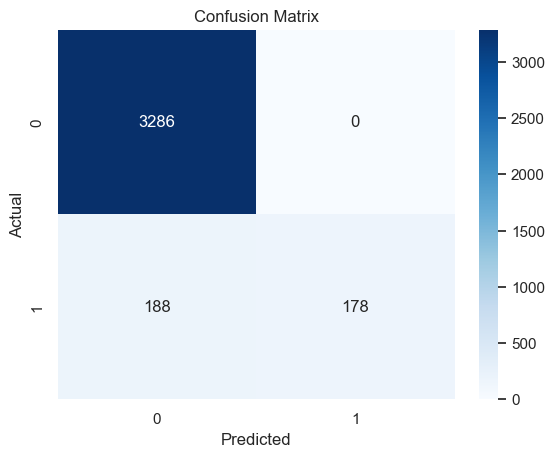

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      3286
           1       1.00      0.49      0.65       366

    accuracy                           0.95      3652
   macro avg       0.97      0.74      0.81      3652
weighted avg       0.95      0.95      0.94      3652



In [58]:
#Confusion Matrix & Classification Report

import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Detailed performance metrics
print("Classification Report:\n", classification_report(y_test, y_test_pred))

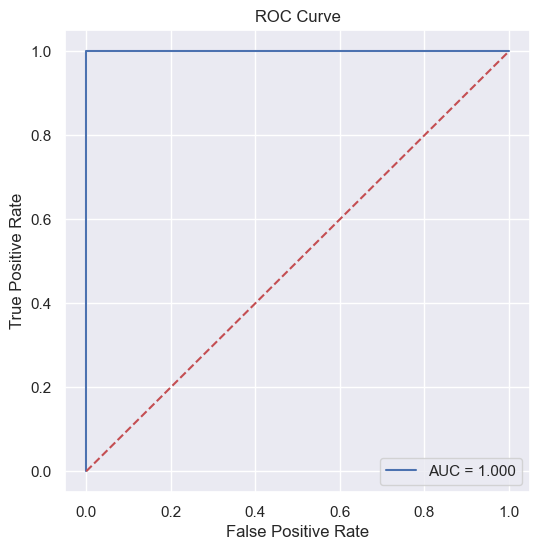

In [61]:
#AUC-ROC Curve (For Binary Classification)

from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:, 1]  # Get probability scores for the positive class
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "r--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

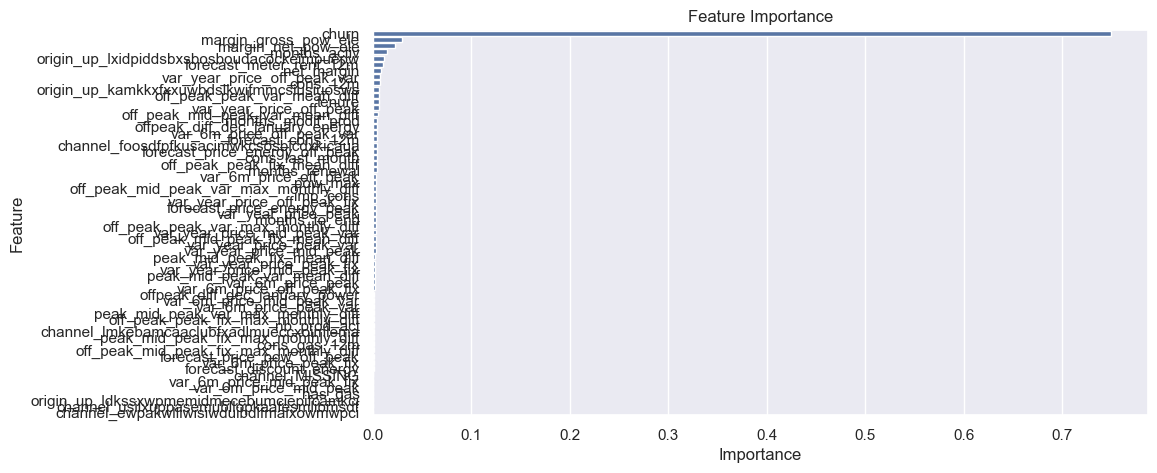

In [62]:
# Feature Importance
import pandas as pd

# Get feature importance scores
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.Importance, y=feature_importance.Feature)
plt.title("Feature Importance")
plt.show()

In [63]:
model.get_params

<bound method BaseEstimator.get_params of RandomForestClassifier(max_depth=5, n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)>

### What These Metrics Tell You:
Accuracy → Measures how often the model is correct.

Confusion Matrix → Shows misclassified examples.

Precision & Recall → Useful for imbalanced datasets.

ROC-AUC → Evaluates the classifier’s ability to differentiate between classes.

Feature Importance → Helps understand which features matter the most.


# Hyperparameter tuning

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="accuracy")


grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_score_

In [ ]:
rf_best = grid_search.best_estimator_
rf_best

In [ ]:
#Visualizing the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[5], feature_names = X.columns,class_names=['Churn', "No Churn"],filled=True);